# Efeito de Esboço a Lápis

Implementação de efeito de esboço a lápis em uma imagem através dos seguintes passos:
1. Converter a imagem colorida para níveis de cinza
2. Aplicar filtro de desfoque gaussiano (máscara 21×21)
3. Dividir a imagem em tons de cinza pela versão desfocada

In [1]:
import cv2
import numpy as np

## Funções Implementadas Manualmente

In [2]:
def converter_para_cinza(img_colorida):
    """
    Converte imagem colorida para escala de cinza usando a fórmula dos pesos:
    Gray = 0.299*R + 0.587*G + 0.114*B
    """
    # OpenCV carrega em BGR
    b = img_colorida[:, :, 0].astype(np.float64)
    g = img_colorida[:, :, 1].astype(np.float64)
    r = img_colorida[:, :, 2].astype(np.float64)
    
    # Aplicar pesos e somar
    cinza = 0.299 * r + 0.587 * g + 0.114 * b
    
    # Converter para uint8
    return np.clip(cinza, 0, 255).astype(np.uint8)

In [3]:
def criar_kernel_gaussiano(tamanho, sigma=0):
    """
    Cria um kernel gaussiano 2D manualmente.
    tamanho: dimensão do kernel (ex: 21 para 21x21)
    sigma: desvio padrão (se 0, calcula automaticamente)
    """
    if sigma == 0:
        sigma = 0.3 * ((tamanho - 1) * 0.5 - 1) + 0.8
    
    # Criar eixos coordenados centrados no meio do kernel
    ax = np.arange(-tamanho // 2 + 1., tamanho // 2 + 1.)
    xx, yy = np.meshgrid(ax, ax)
    
    # Calcular gaussiana 2D
    kernel = np.exp(-(xx**2 + yy**2) / (2. * sigma**2))
    
    # Normalizar para soma = 1
    kernel = kernel / np.sum(kernel)
    
    return kernel

In [4]:
def aplicar_gaussiana(img, kernel):
    """
    Aplica convolução com kernel gaussiano manualmente.
    Usa padding de borda replicada.
    """
    k_size = kernel.shape[0]
    pad = k_size // 2
    
    # Padding da imagem (replicar bordas)
    img_pad = np.pad(img.astype(np.float64), pad, mode='edge')
    
    h, w = img.shape
    resultado = np.zeros_like(img, dtype=np.float64)
    
    # Convolução manual
    for i in range(h):
        for j in range(w):
            # Extrair região de interesse
            regiao = img_pad[i:i+k_size, j:j+k_size]
            # Aplicar kernel e somar
            resultado[i, j] = np.sum(regiao * kernel)
    
    return np.clip(resultado, 0, 255).astype(np.uint8)

In [5]:
def divisor_dodge(cinza, desfocada, escala=255.0):
    """
    Aplica o efeito de divisão (color dodge) para realçar contornos.
    Fórmula: resultado = cinza / (255 - desfocada) * 255
    """
    # Converter para float para evitar overflow
    cinza_f = cinza.astype(np.float64)
    desfocada_f = desfocada.astype(np.float64)
    
    # Evitar divisão por zero
    denominador = 255.0 - desfocada_f
    denominador = np.where(denominador == 0, 1e-10, denominador)
    
    # Aplicar fórmula do color dodge
    esboco = (cinza_f / denominador) * escala
    
    return np.clip(esboco, 0, 255).astype(np.uint8)

## Processamento da Imagem

In [6]:
# Carregar imagem usando OpenCV
imagem = cv2.imread('portrait-handsome-smiling-stylish-young-man-model-wearing-jeans-clothes-sunglasses-fashion-man.jpg')

if imagem is None:
    raise ValueError("Erro ao carregar a imagem!")

print(f"Imagem carregada: {imagem.shape}")

Imagem carregada: (5555, 4166, 3)


### Passo (i): Converter para níveis de cinza

In [7]:
cinza = converter_para_cinza(imagem)
print(f"Imagem em tons de cinza: {cinza.shape}")

# Salvar resultado intermediário
cv2.imwrite('resultado_cinza.jpg', cinza)

Imagem em tons de cinza: (5555, 4166)


True

### Passo (ii): Aplicar filtro gaussiano (21×21)

In [8]:
# Criar kernel gaussiano 21x21
kernel = criar_kernel_gaussiano(21)
print(f"Kernel gaussiano criado: {kernel.shape}")
print(f"Soma do kernel: {np.sum(kernel):.6f}")

# Aplicar desfoque gaussiano
desfocada = aplicar_gaussiana(cinza, kernel)
print(f"Imagem desfocada: {desfocada.shape}")

# Salvar resultado intermediário
cv2.imwrite('resultado_desfocada.jpg', desfocada)

Kernel gaussiano criado: (21, 21)
Soma do kernel: 1.000000
Imagem desfocada: (5555, 4166)


True

### Passo (iii): Dividir cinza pela versão desfocada

In [9]:
# Aplicar efeito de divisão para realçar contornos
esboco = divisor_dodge(cinza, desfocada)
print(f"Esboço final: {esboco.shape}")

# Salvar resultado final
cv2.imwrite('resultado_esboco.jpg', esboco)

print("\nProcessamento concluído!")
print("Arquivos salvos:")
print("  - resultado_cinza.jpg (etapa i)")
print("  - resultado_desfocada.jpg (etapa ii)")
print("  - resultado_esboco.jpg (etapa iii - resultado final)")

Esboço final: (5555, 4166)

Processamento concluído!
Arquivos salvos:
  - resultado_cinza.jpg (etapa i)
  - resultado_desfocada.jpg (etapa ii)
  - resultado_esboco.jpg (etapa iii - resultado final)


## Visualização dos Resultados

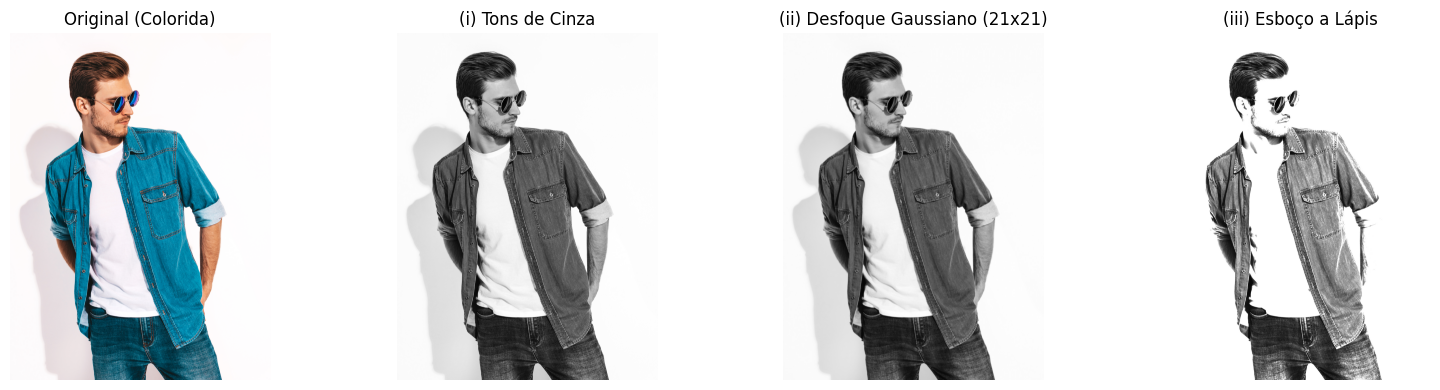

In [11]:
import matplotlib.pyplot as plt

# Carregar resultados para visualização
img_original = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
img_cinza = cv2.imread('resultado_cinza.jpg', 0)
img_desfocada = cv2.imread('resultado_desfocada.jpg', 0)
img_esboco = cv2.imread('resultado_esboco.jpg', 0)

# Criar figura com 4 subplots
plt.figure(figsize=(16, 4))

# Imagem original colorida
plt.subplot(1, 4, 1)
plt.imshow(img_original)
plt.title('Original (Colorida)')
plt.axis('off')

# Passo (i) - Tons de cinza
plt.subplot(1, 4, 2)
plt.imshow(img_cinza, cmap='gray')
plt.title('(i) Tons de Cinza')
plt.axis('off')

# Passo (ii) - Desfocada
plt.subplot(1, 4, 3)
plt.imshow(img_desfocada, cmap='gray')
plt.title('(ii) Desfoque Gaussiano (21x21)')
plt.axis('off')

# Passo (iii) - Esboço final
plt.subplot(1, 4, 4)
plt.imshow(img_esboco, cmap='gray')
plt.title('(iii) Esboço a Lápis')
plt.axis('off')

plt.tight_layout()
plt.savefig('comparativo_esboco.png', dpi=150)
plt.show()